In [23]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
from pathlib import Path

import torch
from transformers import AutoTokenizer, AutoModel


from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate
)
from sklearn.metrics import(
        accuracy_score,
        precision_score,
        recall_score,
        f1_score,
        classification_report,
        confusion_matrix,
        ConfusionMatrixDisplay
)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Imports OK')
print(f'   torch   {torch.__version__}')
print(f'   device  {DEVICE}')


 Imports OK
   torch   2.10.0+cu128
   device  cpu


In [3]:
CSV_PATH = Path('mumin_claims_cardio_diabete_baseline_ready.csv')
if not CSV_PATH.exists():
    raise FileNotFoundError(
        'Filtered dataset not found: mumin_claims_cardio_diabete_baseline_ready.csv\n'
        'Run NB1 first to generate it.'
    )

In [4]:
df = pd.read_csv(CSV_PATH)
print(f'Loaded dataset with {len(df)} records')
print(f'Columns: {df.columns.tolist()}')
print(f'Class distribution:\n{df["label"].value_counts()}')

Loaded dataset with 354 records
Columns: ['text', 'label_name', 'label', 'verdict_norm']
Class distribution:
label
0    337
1     17
Name: count, dtype: int64


In [5]:
BIOBERT_MODEL = 'dmis-lab/biobert-base-cased-v1.2'
tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL)
biobert = AutoModel.from_pretrained(BIOBERT_MODEL).to(DEVICE)
biobert.eval()

print(f'Loaded BioBERT model: {BIOBERT_MODEL}')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: dmis-lab/biobert-base-cased-v1.2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded BioBERT model: dmis-lab/biobert-base-cased-v1.2


In [15]:
def extract_biobert_embeddings(
        texts, tokenizer, model, device, batch_size=16, 
        max_length=512, pooling = 'cls'
):
    all_embeddings = []
    n = len(texts)
    print(f'Extracting BioBERT embeddings for {n} texts...')

    for i in range(0, n, batch_size):
        end =  min(i + batch_size, n)
        batch = list(texts[i:end])
        encodings  = tokenizer(
            batch,
            padding = True,
            truncation = True,
            max_length = max_length,
            return_tensors = 'pt'
        )
        encodings = {k: v.to(device) for k, v in encodings.items()}
        with torch.no_grad():
            outputs = model(**encodings)
        batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.append(batch_embeddings)
        print(f'  Processed {end}/{n} texts', end='\r')
    print('\nDone.')
    result = np.vstack(all_embeddings)
    print(f'Extracted embeddings shape: {result.shape}')
    return result

In [16]:
EMBED_CACHE = 'biobert_embeddings.npy'

if Path(EMBED_CACHE).exists():
    print(f'Loading cached embeddings from {EMBED_CACHE}...')
    X = np.load(EMBED_CACHE)
    print(f'Loaded embeddings shape: {X.shape}')
else:
    X = extract_biobert_embeddings(
        texts = df['text'].values,
        tokenizer = tokenizer,
        model = biobert,
        device = DEVICE,
        batch_size = 16,
        max_length = 512,
        pooling = 'cls'
    )
    np.save(EMBED_CACHE, X)
    print(f'Cached embeddings saved to {EMBED_CACHE}')

Extracting BioBERT embeddings for 354 texts...
  Processed 354/354 texts
Done.
Extracted embeddings shape: (354, 768)
Cached embeddings saved to biobert_embeddings.npy


In [17]:
y = df['label'].values

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, test_size=0.2, random_state=RANDOM_STATE, stratify=y,
)
print('── Split Train / Test ──')
print(f'  Train : {len(X_train)} articles  |  Fake: {(y_train==0).sum()}  Real: {(y_train==1).sum()}')
print(f'  Test  : {len(X_test)}  articles  |  Fake: {(y_test==0).sum()}  Real: {(y_test==1).sum()}')
   

── Split Train / Test ──
  Train : 283 articles  |  Fake: 269  Real: 14
  Test  : 71  articles  |  Fake: 68  Real: 3


In [20]:
clf_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        C=1.0,
        max_iter=1000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LinearSVC(
        C=1.0,
        max_iter=2000,
        random_state=RANDOM_STATE,
        class_weight='balanced'
    ))
])

clf_mlp = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation='relu',
        max_iter=300,
        random_state=RANDOM_STATE,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15
    ))
])

biobert_models = {
    'BioBERT + LR':      clf_lr,
    'BioBERT + LinearSVC': clf_svm,
    'BioBERT + MLP':     clf_mlp,
}

for name in biobert_models:
    print(f'   • {name}')

   • BioBERT + LR
   • BioBERT + LinearSVC
   • BioBERT + MLP


In [24]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_bb = {}

for name, clf in biobert_models.items():
    cv = cross_validate(
        clf, X, y,
        cv=SKF,
        scoring={
            'accuracy'        : 'accuracy',
            'f1_macro'        : 'f1_macro',
            'precision_macro' : 'precision_macro',
            'recall_macro'    : 'recall_macro',
        },
        return_train_score=False,
        n_jobs=-1
    )
    cv_results_bb[name] = cv

    print(f'── {name} ──')
    print(f'  Accuracy  : {cv["test_accuracy"].mean():.4f} ± {cv["test_accuracy"].std():.4f}')
    print(f'  F1 macro  : {cv["test_f1_macro"].mean():.4f} ± {cv["test_f1_macro"].std():.4f}')
    print(f'  Precision : {cv["test_precision_macro"].mean():.4f} ± {cv["test_precision_macro"].std():.4f}')
    print(f'  Recall    : {cv["test_recall_macro"].mean():.4f} ± {cv["test_recall_macro"].std():.4f}')
    print()


── BioBERT + LR ──
  Accuracy  : 0.9350 ± 0.0144
  F1 macro  : 0.5517 ± 0.0882
  Precision : 0.6115 ± 0.1945
  Recall    : 0.5381 ± 0.0652

── BioBERT + LinearSVC ──
  Accuracy  : 0.9492 ± 0.0068
  F1 macro  : 0.6002 ± 0.0946
  Precision : 0.6799 ± 0.1874
  Recall    : 0.5774 ± 0.0706

── BioBERT + MLP ──
  Accuracy  : 0.9520 ± 0.0068
  F1 macro  : 0.4877 ± 0.0018
  Precision : 0.4760 ± 0.0034
  Recall    : 0.5000 ± 0.0000



In [25]:
test_results_bb = {}

for name, clf in biobert_models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    test_results_bb[name] = {
        'y_pred'    : y_pred,
        'accuracy'  : accuracy_score(y_test, y_pred),
        'prec_macro': precision_score(y_test, y_pred, average='macro'),
        'rec_macro' : recall_score(y_test, y_pred, average='macro'),
        'f1_macro'  : f1_score(y_test, y_pred, average='macro'),
        'f1_fake'   : f1_score(y_test, y_pred, pos_label=0),
        'f1_real'   : f1_score(y_test, y_pred, pos_label=1),
    }

    print(f'── {name} — Test Set ──')
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))


── BioBERT + LR — Test Set ──
              precision    recall  f1-score   support

        Fake       0.96      0.94      0.95        68
        Real       0.00      0.00      0.00         3

    accuracy                           0.90        71
   macro avg       0.48      0.47      0.47        71
weighted avg       0.91      0.90      0.91        71

── BioBERT + LinearSVC — Test Set ──
              precision    recall  f1-score   support

        Fake       0.96      1.00      0.98        68
        Real       0.00      0.00      0.00         3

    accuracy                           0.96        71
   macro avg       0.48      0.50      0.49        71
weighted avg       0.92      0.96      0.94        71

── BioBERT + MLP — Test Set ──
              precision    recall  f1-score   support

        Fake       0.96      1.00      0.98        68
        Real       0.00      0.00      0.00         3

    accuracy                           0.96        71
   macro avg       0.48      0

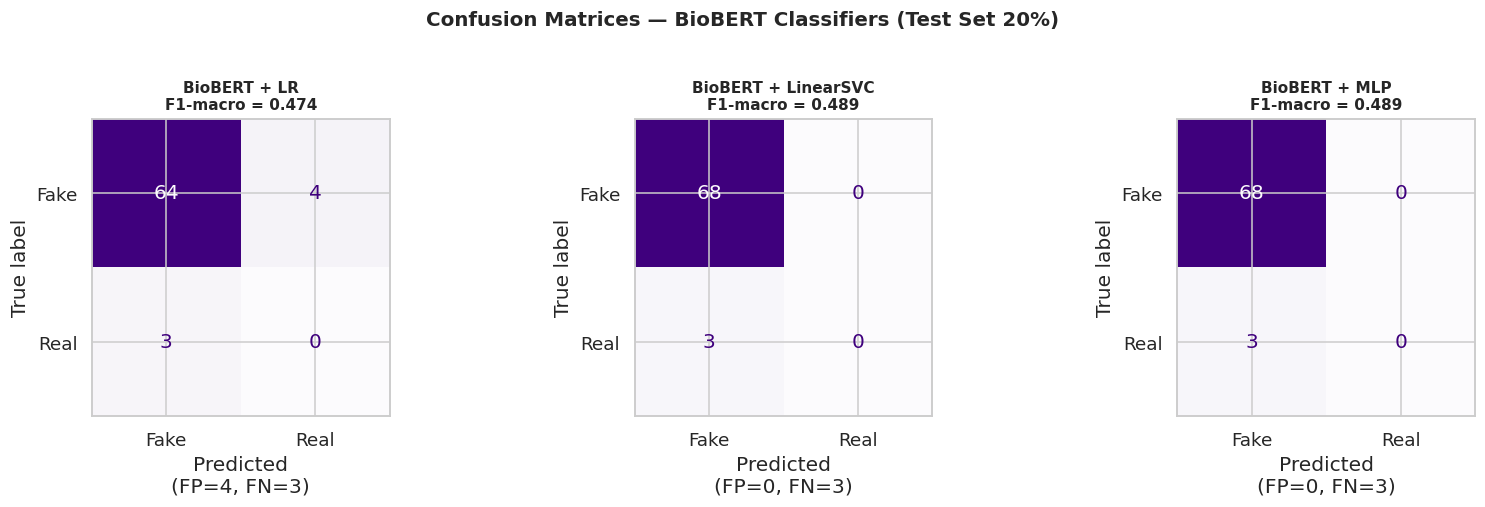

In [26]:
n_models = len(biobert_models)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, test_results_bb.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Fake', 'Real'])
    disp.plot(ax=ax, colorbar=False, cmap='Purples')
    ax.set_title(f'{name}\nF1-macro = {res["f1_macro"]:.3f}',
                 fontsize=10, fontweight='bold')
    fn = cm[1][0]
    fp = cm[0][1]
    ax.set_xlabel(f'Predicted\n(FP={fp}, FN={fn})')

plt.suptitle('Confusion Matrices — BioBERT Classifiers (Test Set 20%)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

plt.show()

